In [2]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [3]:
df = pd.read_csv('bank.csv')
df

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,15606229,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,15569892,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,15584532,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,15682355,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df.drop(columns=['customer_id'], inplace=True)
df

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [5]:
# Converting the categorical data into Boolean for every type of values
# drop_first: biar yang Female gausah disimpen, cuma Male aja
df = pd.get_dummies(df, columns=['country', 'gender'], drop_first=True)
df

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,39,5,0.00,2,1,0,96270.64,0,False,False,True
9996,516,35,10,57369.61,1,1,1,101699.77,0,False,False,True
9997,709,36,7,0.00,1,0,1,42085.58,1,False,False,False
9998,772,42,3,75075.31,2,1,0,92888.52,1,True,False,True


In [6]:
X = df.drop(columns=['churn'])
y = df['churn']

X_train, X_val, y_train, y_val = train_test_split(X, y, train_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_val = scaler.transform(X_val)

In [7]:
# Jumlah fitur yang dimiliki data X
n_features = X_train.shape[1]
n_features

11

# Single Layer Perceptron (SLP)

In [8]:
slp_model = Sequential([  # parameter array layer-layer
    Dense(1, input_shape=(n_features,), activation='sigmoid')  # ini satu layer aja, karena dia SLP; untuk yg input shape, dikosongin supaya modelnya yg ngefit sendiri
])

slp_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

slp_history = slp_model.fit(X_train, y_train, 
                            validation_data=(X_val, y_val), 
                            epochs=160,
                            batch_size=16)

Epoch 1/160
125/125 [==============================] - 0s 3ms/step - loss: 0.7147 - accuracy: 0.5405 - val_loss: 0.6826 - val_accuracy: 0.5800
Epoch 2/160
125/125 [==============================] - 0s 2ms/step - loss: 0.6578 - accuracy: 0.6050 - val_loss: 0.6341 - val_accuracy: 0.6396
Epoch 3/160
125/125 [==============================] - 0s 2ms/step - loss: 0.6127 - accuracy: 0.6650 - val_loss: 0.5949 - val_accuracy: 0.6965
Epoch 4/160
125/125 [==============================] - 0s 2ms/step - loss: 0.5769 - accuracy: 0.7210 - val_loss: 0.5634 - val_accuracy: 0.7366
Epoch 5/160
125/125 [==============================] - 0s 2ms/step - loss: 0.5483 - accuracy: 0.7595 - val_loss: 0.5391 - val_accuracy: 0.7669
Epoch 6/160
125/125 [==============================] - 0s 2ms/step - loss: 0.5255 - accuracy: 0.7875 - val_loss: 0.5190 - val_accuracy: 0.7851
Epoch 7/160
125/125 [==============================] - 0s 2ms/step - loss: 0.5069 - accuracy: 0.8005 - val_loss: 0.5032 - val_accuracy: 0.7936

# Multi Layer Perceptron (MLP)

In [10]:
mlp_model = Sequential([
    Dense(16, input_shape=(n_features,), activation='sigmoid'),
    Dense(8, activation='relu'),
    Dense(1, activation='relu')  # layer output, karena target cuman 1, dikasih 1 aja
])

mlp_model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])

mlp_history = mlp_model.fit(X_train, y_train, 
                            validation_data=(X_val, y_val), 
                            epochs=160,
                            batch_size=32)

Epoch 1/160
63/63 [==============================] - 0s 3ms/step - loss: 3.1621 - accuracy: 0.7950 - val_loss: 3.1357 - val_accuracy: 0.7966
Epoch 2/160
63/63 [==============================] - 0s 2ms/step - loss: 3.1621 - accuracy: 0.7950 - val_loss: 3.1357 - val_accuracy: 0.7966
Epoch 3/160
63/63 [==============================] - 0s 2ms/step - loss: 3.1621 - accuracy: 0.7950 - val_loss: 3.1357 - val_accuracy: 0.7966
Epoch 4/160
63/63 [==============================] - 0s 2ms/step - loss: 3.1621 - accuracy: 0.7950 - val_loss: 3.1357 - val_accuracy: 0.7966
Epoch 5/160
63/63 [==============================] - 0s 2ms/step - loss: 3.1621 - accuracy: 0.7950 - val_loss: 3.1357 - val_accuracy: 0.7966
Epoch 6/160
63/63 [==============================] - 0s 2ms/step - loss: 3.1621 - accuracy: 0.7950 - val_loss: 3.1357 - val_accuracy: 0.7966
Epoch 7/160
63/63 [==============================] - 0s 2ms/step - loss: 3.1621 - accuracy: 0.7950 - val_loss: 3.1357 - val_accuracy: 0.7966
Epoch 8/160
6

In [11]:
def plot_metrics(history, model_name):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(1, len(acc) + 1)
    
    plt.figure(figsize=(12,4))
    
    plt.subplot(1,2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy', color='blue')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy', color='red')
    plt.title(f"{model_name} - Accuracy")
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1,2, 2)
    plt.plot(epochs_range, loss, label='Training Loss', color='blue')
    plt.plot(epochs_range, val_loss, label='Validation Loss', color='red')
    plt.title(f"{model_name} - Loss")
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

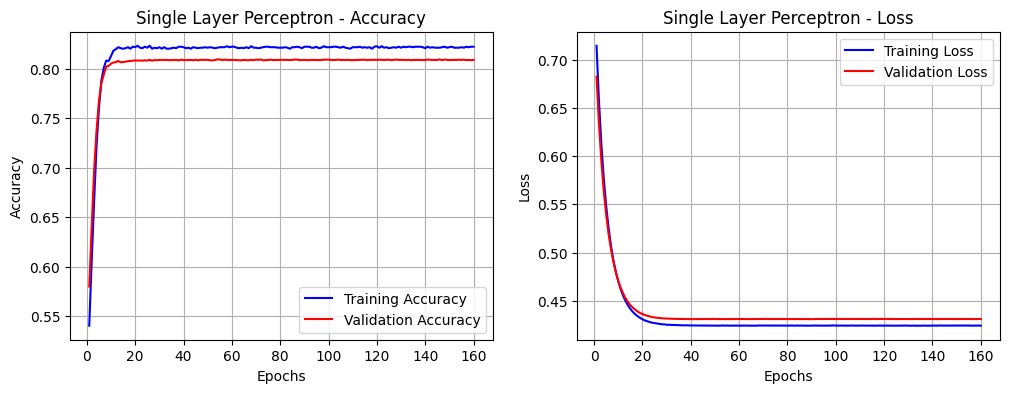

In [12]:
plot_metrics(slp_history, 'Single Layer Perceptron')

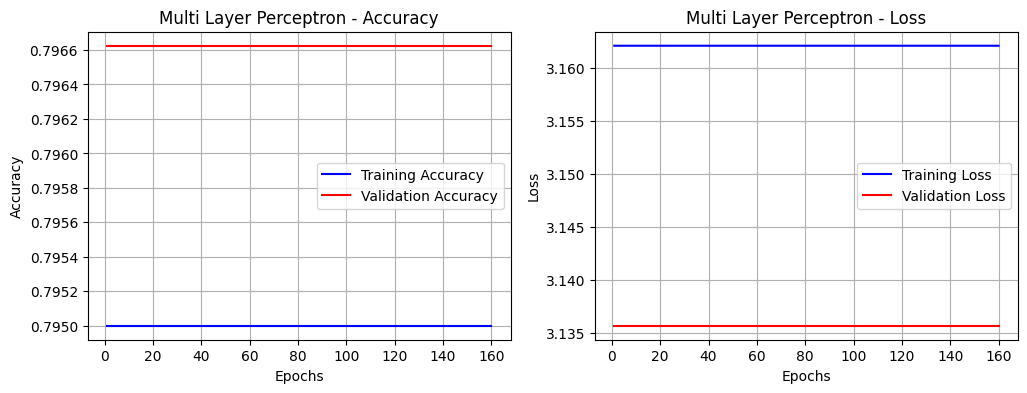

In [13]:
plot_metrics(mlp_history, 'Multi Layer Perceptron')